# Datasets

> Definitions of various data sets used in learning with offline rollouts.

In [1]:
#| default_exp data.datasets

In [2]:
#| hide
from nbdev.showdoc import *

In [3]:
#| export
import os
import h5py
import numpy as np

import torch
from torch.utils.data import Dataset
import torch.nn.functional as F

from fastcore import *
from fastcore.utils import *

## VQ-VAE Dataset

In [3]:
#| export

class MultiAgentPOVDataset(Dataset):

    def __init__(self, h5_path, split="train", val_ratio=0.1, transform=None):
        """Args:

        h5_path (str): Path to the h5 dataset file.
        split (str): 'train' or 'val' to specify the dataset split.
        val_ratio (float): Fraction of episodes to allocate to the validation
        set.
        transform (callable, optional): Unified transform pipeline.
        """
        assert split in ["train", "val"], "split must be 'train' or 'val'"
        self.h5_path = h5_path
        self.split = split
        self.transform = transform

        # Initialized as None for PyTorch multi-process DataLoader safety
        self.file = None
        self.index_map = []

        # Open temporarily to inspect structure and build split mappings
        with h5py.File(self.h5_path, "r") as f:
            # 1. Gather all episode keys and sort them so the split is deterministic
            all_episodes = sorted(list(f.keys()))
            num_episodes = len(all_episodes)

            # 2. Calculate the split boundary index
            val_count = int(num_episodes * val_ratio)
            train_count = num_episodes - val_count

            # 3. Partition the actual episode groups (Episode-level splitting)
            if self.split == "train":
                active_episodes = all_episodes[:train_count]
            else:
                active_episodes = all_episodes[train_count:]

            # 4. Build the index map *only* using the active episodes for this split
            for episode_key in active_episodes:
                episode_group = f[episode_key]
                num_frames = np.min(episode_group['agents_success_at']).item()#episode_group["0_pov"].shape[0]

                for frame_idx in range(num_frames):
                    self.index_map.append((episode_key, frame_idx, "0_pov"))
                    self.index_map.append((episode_key, frame_idx, "1_pov"))

        print(
            f"Initialized {self.split} split with {len(active_episodes)} episodes ({len(self.index_map)} total agent frames)."
        )

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        if self.file is None:
            self.file = h5py.File(self.h5_path, "r")

        episode_key, frame_idx, agent_pov_key = self.index_map[idx]
        frame = self.file[episode_key][agent_pov_key][frame_idx]

        if self.transform:
            frame = self.transform(frame)

        return frame

    def close(self):
        if self.file is not None:
            self.file.close()
            self.file = None


In [4]:
#| hide
import torch
from torch.utils.data import DataLoader
from c3jepa_wm.data.transforms import get_transforms

vqvae_transforms = get_transforms()[0]
# Initialize dataset
dataset = MultiAgentPOVDataset(
    h5_path="./exp/data/dataset.h5", transform=vqvae_transforms
)

# Create DataLoader
# Note: setting num_workers > 0 works perfectly now because of the lazy file opening!
dataloader = DataLoader(
    dataset, batch_size=64, shuffle=True, num_workers=4, drop_last=True
)

# Training loop snippet
for batch_idx, x in enumerate(dataloader):
    # x will be shape: [batch_size, 3, height, width]
    # Pass x into your VQ-VAE
    pass

# Clean up file handles cleanly at the end of the script
dataset.close()

Initialized train split with 9 episodes (270 total agent frames).


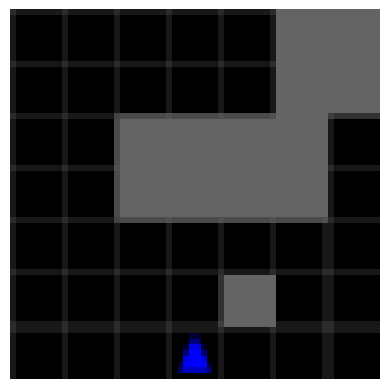

In [12]:
#| hide
import matplotlib.pyplot as plt
sample = dataset[11]

denormalize = lambda x: (x * 0.5) + 0.5
sample_np = denormalize(sample).permute(1, 2, 0).numpy() # Scale back to [0, 1]

plt.imshow(sample_np)
plt.axis('off')
plt.savefig("without_resize.png")
plt.show()

## World Models Dataset

In [ ]:
#| export
class MultiAgentWorldModelDataset(Dataset):
    def __init__(
        self,
        h5_path,
        split="train",
        val_ratio=0.1,
        history_size=3,        # T: number of frames fed to predictor
        num_preds= 1,          # number of future frames to predict (currently only supports 1)
        receiver_transform=None,
        sender_transform=None,
    ):
        assert split in ["train", "val"], "split must be 'train' or 'val'"
        self.h5_path = h5_path
        self.split = split
        self.receiver_transform = receiver_transform
        self.sender_transform = sender_transform
        self.history_size = history_size
        self.num_preds = num_preds
        self.file = None
        self.index_map = []

        with h5py.File(self.h5_path, "r") as f:
            all_episodes = sorted(list(f.keys()))
            num_episodes = len(all_episodes)
            val_count = int(num_episodes * val_ratio)
            train_count = num_episodes - val_count

            if self.split == "train":
                active_episodes = all_episodes[:train_count]
            else:
                active_episodes = all_episodes[train_count:]

            for episode_key in active_episodes:
                episode_group = f[episode_key]
                num_frames = np.min(
                    episode_group['agents_success_at']
                ).item()

                # Need history_size frames + 1 target frame
                # so valid start indices are [0, num_frames - history_size - 1]
                for start_idx in range(num_frames - history_size - num_preds):
                    # Alternate sender/receiver between agents to save training time
                    # Even indices: agent 0 is sender, agent 1 is receiver
                    # Odd indices:  agent 1 is sender, agent 0 is receiver
                    self.index_map.append((episode_key, start_idx, "0", "1"))
                    self.index_map.append((episode_key, start_idx, "1", "0"))

        print(
            f"Initialized {self.split} split with {len(active_episodes)} episodes "
            f"({len(self.index_map)} total sequence pairs)."
        )

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        if self.file is None:
            self.file = h5py.File(self.h5_path, "r")

        episode_key, start_idx, sender_id, receiver_id = self.index_map[idx]
        episode = self.file[episode_key]
        end_idx = start_idx + self.history_size  # exclusive, this is the target frame

        # ── Receiver fields ──────────────────────────────────────────────
        # POV frames: history_size frames as input, +1 as prediction target
        receiver_pov_seq = episode[f"{receiver_id}_pov"][start_idx : end_idx + self.num_preds]  # (T+num_preds, H, W, C)
        receiver_act_seq = episode[f"{receiver_id}_act"][start_idx : end_idx]      # (T,)

        # ── Sender fields ─────────────────────────────────────────────────
        # We only need the sender's POV at the last history frame
        # (the frame whose encoding becomes the message)
        # sender_pov = episode[f"{sender_id}_pov"][end_idx - 1]                      # (H, W, C)
        # sender_csi = episode[f"{sender_id}_csi"][end_idx - 1]                      # complex scalar

        sender_pov_seq = episode[f"{sender_id}_pov"][start_idx : end_idx]  # (T, H, W, C)
        sender_csi_seq = episode[f"{sender_id}_csi"][start_idx : end_idx]  # (T,) complex

        # ── Apply transforms to POV frames ────────────────────────────────
        if self.receiver_transform:
            # Transform each frame independently
            receiver_pov_seq = torch.stack(
                [self.receiver_transform(receiver_pov_seq[t]) for t in range(self.history_size + 1)]
            )                    
            
        else:
            receiver_pov_seq = torch.from_numpy(receiver_pov_seq).float() / 255.0
            
                                                                # (T+1, C, H, W)
        if self.sender_transform:
            # sender_pov = self.sender_transform(sender_pov)                                 # (C, H, W)
            sender_pov = torch.stack(
                [self.sender_transform(sender_pov_seq[t]) for t in range(self.history_size)]
            )  
            
        else:
            sender_pov = torch.from_numpy(sender_pov_seq).float() / 255.0

        return {
            # Receiver inputs
            "pixels": receiver_pov_seq,           # (T+1, C, H, W) — first T are history, last is target
            "action": torch.tensor(
                receiver_act_seq, dtype=torch.long
            ),                                               # (T,) discrete actions

            # Sender inputs (for VQ-VAE message extraction)
            "sender_pov": sender_pov,                       # (C, H, W)
            "sender_csi": torch.tensor(
                sender_csi_seq, dtype=torch.complex64
            ),                                               # scalar complex
        }

    def close(self):
        if self.file is not None:
            self.file.close()
            self.file = None
    

In [10]:
#| hide
ds = MultiAgentWorldModelDataset(
    h5_path="./exp/data/dataset.h5",
    split="train",
    history_size=7,
    num_preds=1,
)



Initialized train split with 9 episodes (196 total sequence pairs).


In [11]:
#| hide
sample = ds[0]
sample.keys()

dict_keys(['pixels', 'action', 'sender_pov', 'sender_csi'])

In [12]:
#| hide
for k, v in sample.items():
    print(f"{k}: {v.shape}, dtype={v.dtype}")

pixels: torch.Size([8, 224, 224, 3]), dtype=torch.float32
action: torch.Size([7]), dtype=torch.int64
sender_pov: torch.Size([7, 224, 224, 3]), dtype=torch.float32
sender_csi: torch.Size([7, 1, 1]), dtype=torch.complex64


## Planning Dataset

In [ ]:
#| export
class MultiAgentPlanningDataset(Dataset):
    """
    Dataset for online planning evaluation. Unlike MultiAgentWorldModelDataset
    (which yields single sender/receiver training windows), this yields one
    full episode at a time for *both* agents, so the evaluator can choose its
    own t0 / goal_offset and build messages for either agent acting as sender.

    Returns, per episode:
        {
            "agent_0": {"pixels": (T, C, H, W), "action": (T,)},
            "agent_1": {"pixels": (T, C, H, W), "action": (T,)},
            "episode_key": str,
            "length": int,
        }
    """

    def __init__(
        self,
        h5_path,
        split="train",
        val_ratio=0.1,
        agents=("0", "1"),
        jepa_transform=None,
        vqvae_transform=None,
        max_length=None,
        min_length= 1
    ):
        assert split in ["train", "val"], "split must be 'train' or 'val'"
        self.h5_path = h5_path
        self.split = split
        self.agents = list(agents)
        self.jepa_transform = jepa_transform
        self.vqvae_transform = vqvae_transform
        self.max_length = max_length
        self.file = None

        # with h5py.File(self.h5_path, "r") as f:
        #     all_episodes = sorted(list(f.keys()))
        #     num_episodes = len(all_episodes)
        #     val_count = int(num_episodes * val_ratio)
        #     train_count = num_episodes - val_count

        #     self.episode_keys = (
        #         all_episodes[:train_count] if self.split == "train" else all_episodes[train_count:]
        #     )
        with h5py.File(self.h5_path, "r") as f:
            all_episodes = sorted(list(f.keys()))
            # drop episodes with degenerate (<= 0, or < min_length) success horizon
            valid_episodes = [
                k for k in all_episodes
                if np.min(f[k]["agents_success_at"]) >= min_length
            ]
            dropped = len(all_episodes) - len(valid_episodes)
            if dropped:
                print(f"[MultiAgentPlanningDataset] dropped {dropped} degenerate episode(s) "
                    f"with agents_success_at < {min_length}")
            num_episodes = len(valid_episodes)
            val_count = int(num_episodes * val_ratio)
            train_count = num_episodes - val_count
            self.episode_keys = (
                valid_episodes[:train_count] if split == "train" else valid_episodes[train_count:]
            )

        print(f"Initialized {self.split} planning split with {len(self.episode_keys)} episodes.")

    def __len__(self):
        return len(self.episode_keys)

    def _load_agent(self, episode, agent_id, length):
        pov_seq = episode[f"{agent_id}_pov"][:length]       # (T, H, W, C)
        act_seq = episode[f"{agent_id}_act"][:length]        # (T,)
        csi_seq = episode[f"{agent_id}_csi"][:length]        # (T,) complex

        if self.jepa_transform:
            pov_seq = torch.stack([self.jepa_transform(pov_seq[t]) for t in range(length)])  # (T, C, H, W)

        if self.vqvae_transform:
            pov_seq_vqvae = torch.stack([self.vqvae_transform(pov_seq[t]) for t in range(length)])  # (T, C, H, W)

        act_seq = torch.tensor(act_seq, dtype=torch.long)  # (T,)
        csi_seq = torch.tensor(csi_seq, dtype=torch.complex64)  # (T,)
        return pov_seq, act_seq, pov_seq_vqvae, csi_seq

    def __getitem__(self, idx):
        if self.file is None:
            self.file = h5py.File(self.h5_path, "r")

        episode_key = self.episode_keys[idx]
        episode = self.file[episode_key]
        success_at = np.asarray(episode["agents_success_at"]) 
        length = np.min(episode["agents_success_at"]).item()
        if self.max_length is not None:
            length = min(length, self.max_length)

        out = {"episode_key": episode_key, "length": length, "success_at": success_at}
        for agent_id in self.agents:
            pixels, action, pov_seq_vqvae, csi_seq = self._load_agent(episode, agent_id, length)
            out[f"agent_{agent_id}"] = {"pixels": pixels, "action": action, "pov_seq_vqvae": pov_seq_vqvae, "csi": csi_seq,
                                        "success_at": success_at
                                        }

        return out

    def close(self):
        if self.file is not None:
            self.file.close()
            self.file = None
            

In [10]:
#| hide
import torchvision
ds = MultiAgentPlanningDataset(
    h5_path="./exp/data/dataset.h5",
    split="val",
    val_ratio=0.1,
    agents=("0", "1"),
    # transform=None,
    vqvae_transform= torchvision.transforms.Compose([
        torchvision.transforms.ToPILImage(),
        torchvision.transforms.Resize((64, 64)),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]),
    max_length=None,
)



Initialized val planning split with 1 episodes.


In [11]:
#| hide
sample = ds[0]
sample.keys()

dict_keys(['episode_key', 'length', 'agent_0', 'agent_1'])

In [12]:
#| hide
sample['agent_0']['pixels'].shape, sample['agent_0']['action'].shape

((18, 224, 224, 3), torch.Size([18]))

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()